## CAI6108: Machine Learning Engineering Project

**Team:** Sanjith Devineni, Sai Neha Ratakonda, Abhignan Sai Arcot, Sahith Reddy Gopidi, Akshay Jaidi  
**Task:** Multi-label image classification — 12 object classes, 128×128 PNG images.

## Section 1 — Imports & Config

In [1]:
import sys
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import hamming_loss, f1_score

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 12})

print('------------')
print('Python  :', sys.version)
print('NumPy   :', np.__version__)
print('sklearn :', sklearn.__version__)
print('PyTorch :', torch.__version__)
print('------------')

------------
Python  : 3.12.1 (v3.12.1:2305ca5144, Dec  7 2023, 17:23:38) [Clang 13.0.0 (clang-1300.0.29.30)]
NumPy   : 1.26.4
sklearn : 1.5.1
PyTorch : 2.10.0
------------


In [2]:
# =============================================================
# Config — change these variables to control all training runs
# =============================================================
SEED        = 42        # global RNG seed for reproducibility
BATCH_SIZE  = 32        # images per mini-batch
NUM_EPOCHS  = 2 # 15        # total training epochs
THRESHOLD   = 0.5       # sigmoid cutoff: probability >= THRESHOLD → predicted positive
IMG_SIZE    = 128       # model input resolution in pixels (must match eval.py default)
LR          = 1e-4      # Adam learning rate
STEP_SIZE   = 5         # StepLR: decay LR every N epochs
GAMMA       = 0.5       # StepLR: multiply LR by this factor at each decay step
NUM_CLASSES = 12        # total number of object classes
NUM_WORKERS = 0         # DataLoader worker processes (0 = main process only, safest for notebooks)

DATASET_DIR = Path('dataset')   # root directory containing label-combo subdirectories
CHECKPOINT  = 'best_model.pth'  # filename for the best checkpoint (saved by val F1)

# Canonical label order — must match eval.py LABEL_ORDER exactly
CLASS_NAMES = [
    'pen', 'paper', 'book', 'clock', 'phone', 'laptop',
    'chair', 'desk', 'bottle', 'keychain', 'backpack', 'calculator'
]

prop_vec = [16, 2, 2]   # train : val : test proportions
epsf     = 1e-9          # small epsilon for numerical stability

# Set all random seeds at once for reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'Classes: {CLASS_NAMES}')

Device : cpu
Classes: ['pen', 'paper', 'book', 'clock', 'phone', 'laptop', 'chair', 'desk', 'bottle', 'keychain', 'backpack', 'calculator']


## Section 2 — Data Exploration

Scan folders in dataset to build a flat DataFrame and an `all_samples` list used throughout the notebook.

**Important items:**
- Total image count and shape of the DataFrame
- Per-class counts — classes with very low counts may underperform at test time
- Average labels per image — tells you how multi-label the problem actually is
- Sample images — check that the 128×128 images are clean and labels look correct

In [3]:
# Build (image_path, label_tensor) pairs by parsing folder names.
# This mirrors eval.py's CustomDirectoryLayoutDataset logic exactly.
VALID_LABELS = set(CLASS_NAMES)
IMG_RE = re.compile(r'^img\S+\.png$', re.IGNORECASE)  # matches imgN.png filenames

records     = []  # rows for the exploration DataFrame
all_samples = []  # (Path, label_tensor) pairs used for splits and Dataset objects

for subdir in sorted(DATASET_DIR.iterdir()):
    if not subdir.is_dir():
        continue
    labels = subdir.name.split('_')
    if not labels or any(lbl not in VALID_LABELS for lbl in labels):
        continue  # skip non-label directories (e.g. hidden folders)
    if len(labels) != len(set(labels)):
        continue  # skip folders with duplicate labels in their name

    # Build a multi-hot target vector of length NUM_CLASSES
    target = torch.zeros(NUM_CLASSES, dtype=torch.float32)
    for i, cls in enumerate(CLASS_NAMES):
        if cls in labels:
            target[i] = 1.0

    for img_path in sorted(subdir.iterdir()):
        if img_path.is_file() and IMG_RE.match(img_path.name):
            all_samples.append((img_path, target.clone()))
            row = {'image_path': str(img_path), 'label_combo': subdir.name}
            for cls in CLASS_NAMES:
                row[cls] = int(cls in labels)
            records.append(row)

df = pd.DataFrame(records)
print(f'Total images   : {len(df)}')
print(f'DataFrame shape: {df.shape}')
print(f'\nColumn names: {list(df.columns)}')
print('\nFirst 3 rows:')
df.head(3)

Total images   : 4543
DataFrame shape: (4543, 14)

Column names: ['image_path', 'label_combo', 'pen', 'paper', 'book', 'clock', 'phone', 'laptop', 'chair', 'desk', 'bottle', 'keychain', 'backpack', 'calculator']

First 3 rows:


,image_path,label_combo,pen,paper,book,clock,phone,laptop,chair,desk,bottle,keychain,backpack,calculator
0,dataset/backpack/img1.png,backpack,0,0,0,0,0,0,0,0,0,0,1,0
1,dataset/backpack/img100.png,backpack,0,0,0,0,0,0,0,0,0,0,1,0
2,dataset/backpack/img102.png,backpack,0,0,0,0,0,0,0,0,0,0,1,0


In [4]:
# Per-class image counts (how many images contain each class)
class_counts = df[CLASS_NAMES].sum().astype(int).sort_values(ascending=False)
print('Per-class image counts (sorted high to low):')
print('=' * 40)
for cls, cnt in class_counts.items():
    bar = '|' * (cnt // 40)
    print(f'  {cls:<12} {cnt:>4}  {bar}')

labels_per_image = df[CLASS_NAMES].sum(axis=1)
print(f'\nAvg labels per image: {labels_per_image.mean():.2f}')
print(f'Min labels per image: {int(labels_per_image.min())}')
print(f'Max labels per image: {int(labels_per_image.max())}')

Per-class image counts (sorted high to low):
  pen           765  |||||||||||||||||||
  bottle        736  ||||||||||||||||||
  book          728  ||||||||||||||||||
  laptop        728  ||||||||||||||||||
  paper         713  |||||||||||||||||
  phone         711  |||||||||||||||||
  calculator    648  ||||||||||||||||
  chair         627  |||||||||||||||
  keychain      626  |||||||||||||||
  backpack      614  |||||||||||||||
  desk          588  ||||||||||||||
  clock         503  ||||||||||||

Avg labels per image: 1.76
Min labels per image: 1
Max labels per image: 7


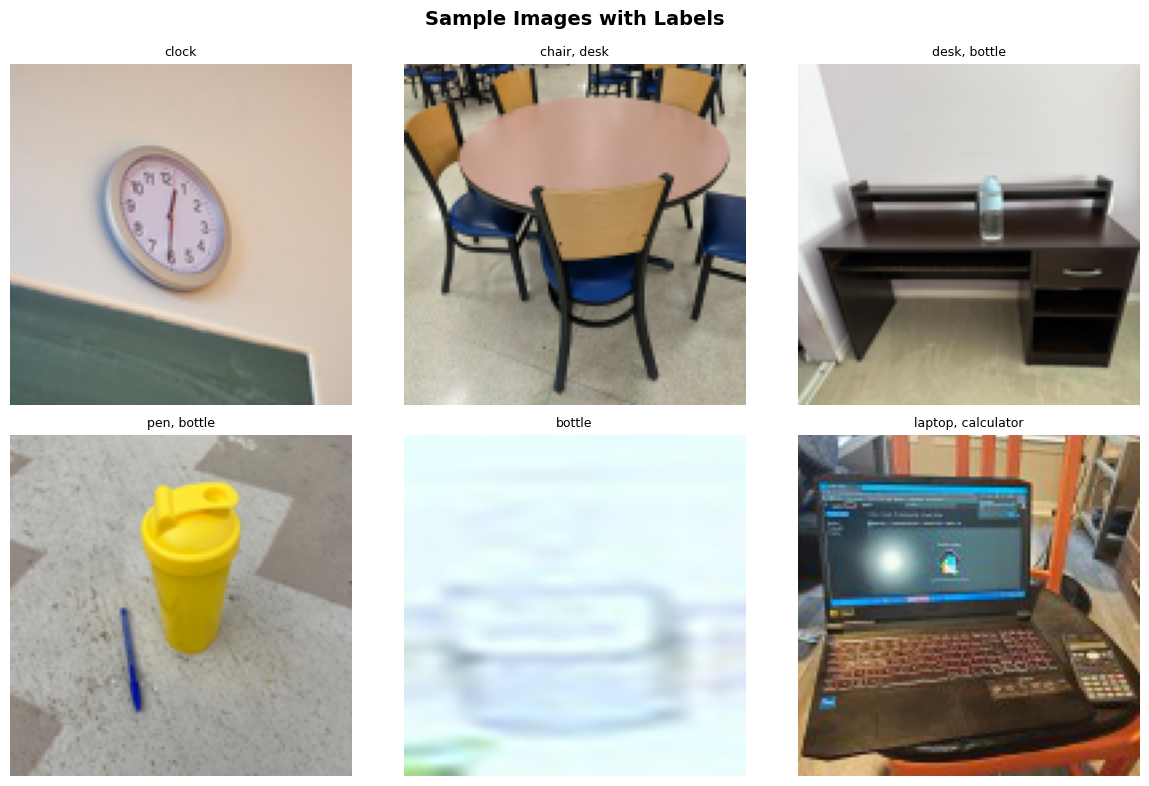

In [5]:
# Display 6 sample images with their active labels
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
sample_rows = df.sample(6, random_state=SEED).reset_index(drop=True)

for ax, (_, row) in zip(axes.flat, sample_rows.iterrows()):
    img = Image.open(row['image_path']).convert('RGB')
    ax.imshow(img)
    active = [cls for cls in CLASS_NAMES if row[cls] == 1]
    ax.set_title(', '.join(active), fontsize=9)
    ax.axis('off')

plt.suptitle('Sample Images with Labels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 3 — Dataset Class & Transforms

`MultiLabelDataset` wraps a pre-built list of `(image_path, label_tensor)` pairs.
Using a pre-built list means we can apply **different transforms** to the same underlying
files without re-scanning the filesystem for each split.

**Transforms:**
- `train_transform` adds random flips and colour jitter for augmentation.
- `eval_transform` only resizes and normalises — no randomness, for deterministic eval.
- Both use **ImageNet mean/std** because EfficientNet-B0 was pretrained on ImageNet.

In [6]:
class MultiLabelDataset(Dataset):
    """PyTorch Dataset for multi-label image classification.

    Wraps a pre-built list of (image_path, label_tensor) pairs so the same
    samples list can be reused across train/val/test splits without
    re-scanning the filesystem each time.
    """

    def __init__(self, samples, transform=None):
        """
        Args:
            samples: List of (Path, torch.Tensor) -- image path + float32 label vector.
            transform: Optional torchvision transform applied to each PIL image.
        """
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        """Return total number of samples."""
        return len(self.samples)

    def __getitem__(self, idx):
        """Load one image and its label vector."""
        img_path, target = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        return image, target


# ImageNet normalisation — required because the EfficientNet-B0 backbone
# was pretrained on ImageNet and expects these exact statistics.
_IMAGENET_MEAN = [0.485, 0.456, 0.406]
_IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),                         # random left-right flip
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.2, hue=0.05),          # mild colour augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=_IMAGENET_MEAN, std=_IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=_IMAGENET_MEAN, std=_IMAGENET_STD),
])

print('Transforms defined.')
print('train_transform:', train_transform)

Transforms defined.
train_transform: Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## Section 4 — Train / Val / Test Split & DataLoaders

`prop_vec = [16, 2, 2]` encodes an 80 / 10 / 10 split.  
We split at the **image level** using `sklearn.model_selection.train_test_split` with
`random_state=SEED` so we get the same split every run.

The three DataLoaders feed each section of the training loop.

In [7]:
# prop_vec = [16, 2, 2]  →  80% train / 10% val / 10% test
total_parts = sum(prop_vec)                               # 20
temp_frac   = (prop_vec[1] + prop_vec[2]) / total_parts  # 0.20 held out for val+test

# First split: carve out 20% for the temporary val+test pool
train_samples, temp_samples = train_test_split(
    all_samples, test_size=temp_frac, random_state=SEED
)
# Second split: divide temp pool 50/50 into val and test
val_samples, test_samples = train_test_split(
    temp_samples, test_size=0.5, random_state=SEED
)

print(f'Split sizes:  train={len(train_samples)}  val={len(val_samples)}  test={len(test_samples)}')

train_dataset = MultiLabelDataset(train_samples, transform=train_transform)
val_dataset   = MultiLabelDataset(val_samples,   transform=eval_transform)
test_dataset  = MultiLabelDataset(test_samples,  transform=eval_transform)

_pin = torch.cuda.is_available()  # pin_memory speeds up GPU transfers; skip on CPU/MPS

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=_pin)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=_pin)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=_pin)

print(f'DataLoaders: {len(train_loader)} train batches | {len(val_loader)} val | {len(test_loader)} test')

Split sizes:  train=3634  val=454  test=455
DataLoaders: 114 train batches | 15 val | 15 test


## Section 5 — Baseline Model

**Approach:** flatten each 32×32 RGB image to a 3072-dimensional vector, then fit one
`LogisticRegression` binary classifier per class using `OneVsRestClassifier`.
No learned features — raw pixel values only.

**Purpose:** establishes a lower bound. Our deep model (Section 6) must beat these numbers.
Record **Hamming Loss** and **Macro F1** here for the report's Results table.

In [8]:
BASELINE_SIZE = 32  # cheap 32x32 pixel features — coarser than the main model

def extract_pixel_features(samples, size=BASELINE_SIZE):
    """Flatten resized RGB images into 1-D numpy feature vectors (size*size*3 dims)."""
    resize_tf = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
    ])
    X, Y = [], []
    for img_path, target in samples:
        img    = Image.open(img_path).convert('RGB')
        tensor = resize_tf(img)              # shape (3, size, size)
        X.append(tensor.numpy().flatten())   # flatten to 1-D array of length size*size*3
        Y.append(target.numpy())
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)


print('Extracting baseline pixel features (may take ~30 s)...')
X_train_bl, y_train_bl = extract_pixel_features(train_samples)
X_val_bl,   y_val_bl   = extract_pixel_features(val_samples)
print(f'Feature shapes -- X_train: {X_train_bl.shape}  y_train: {y_train_bl.shape}')

# OneVsRestClassifier trains one binary LR per class; n_jobs=-1 runs them in parallel
baseline_clf = OneVsRestClassifier(
    LogisticRegression(max_iter=200, C=0.1, solver='liblinear', random_state=SEED),
    n_jobs=-1
)
baseline_clf.fit(X_train_bl, y_train_bl)

y_val_pred_bl = baseline_clf.predict(X_val_bl)

bl_hamming  = hamming_loss(y_val_bl, y_val_pred_bl)
bl_f1_macro = f1_score(y_val_bl, y_val_pred_bl, average='macro', zero_division=0)

print('\n' + '=' * 48)
print('Baseline Model (Logistic Regression) -- Val Set')
print('=' * 48)
print(f'  Hamming Loss  : {bl_hamming:.4f}   (lower is better)')
print(f'  Macro F1      : {bl_f1_macro:.4f}   (higher is better)')
print('=' * 48)
print('  >> Record these numbers in the project report.')

Extracting baseline pixel features (may take ~30 s)...
Feature shapes -- X_train: (3634, 3072)  y_train: (3634, 12)

Baseline Model (Logistic Regression) -- Val Set
  Hamming Loss  : 0.1476   (lower is better)
  Macro F1      : 0.1597   (higher is better)
  >> Record these numbers in the project report.


## Section 6 — Main Model (EfficientNet-B0)

We use **EfficientNet-B0** pretrained on ImageNet as a feature extractor (transfer learning).
The final linear layer is replaced with `Linear(1280, NUM_CLASSES)` outputting **raw logits**
(one per class). Probabilities are obtained via `torch.sigmoid(logits)` at inference time.

Loss: `BCEWithLogitsLoss` — numerically stable sigmoid + binary cross-entropy combined.  
Optimizer: Adam with `lr=LR`.  
Schedule: StepLR — halve LR every `STEP_SIZE` epochs to refine convergence.

**`create_model` is also used in Section 9 (eval.py compatibility) and must be kept
in sync with the checkpoint format.**

In [9]:
def create_model(num_labels=NUM_CLASSES, pretrained=False):
    """Build EfficientNet-B0 with a custom multi-label classification head.

    Args:
        num_labels: Number of output logits (one per class).
        pretrained: If True, load ImageNet backbone weights for transfer learning.
                    Set False when a state dict will be loaded immediately after
                    (avoids an unnecessary download, e.g. in eval.py).
    Returns:
        nn.Module: EfficientNet-B0 with head replaced by Linear(1280, num_labels).
    """
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
    model   = efficientnet_b0(weights=weights)
    in_features = model.classifier[1].in_features   # 1280 for EfficientNet-B0
    model.classifier[1] = nn.Linear(in_features, num_labels)  # swap head
    return model


# Load ImageNet pretrained backbone for transfer learning
model = create_model(num_labels=NUM_CLASSES, pretrained=True).to(DEVICE)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(model.parameters(), lr=LR)

# Multiply LR by GAMMA every STEP_SIZE epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)

# Quick sanity check: one forward pass on random input
with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = model(dummy)
    print(f'Output shape: {list(out.shape)}  (expected [2, {NUM_CLASSES}])')

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total_params:,}')
print(f'Trainable params: {trainable_params:,}')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/sanjithdevineni/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20.5M/20.5M [00:00<00:00, 32.9MB/s]


Output shape: [2, 12]  (expected [2, 12])
Total params    : 4,022,920
Trainable params: 4,022,920


## Section 7 — Training Loop

Each epoch:
1. **Train pass** — forward, BCEWithLogitsLoss, backward, Adam step.
2. **Val pass** — no gradients; compute val loss, Macro F1, Hamming Loss.
3. **Checkpoint** — save `best_model.pth` whenever val F1 improves.

**Checkpoint note:** we save only the **state dict** (not the full model object)
because `eval.py` reloads with `model.load_state_dict(torch.load(path))`.  
Saving the full object with `torch.save(model, ...)` would break that loading.

After training runs, Section 8 reloads `best_model.pth` for final test evaluation.

In [10]:
def compute_val_metrics(model, loader, criterion, device, threshold=THRESHOLD):
    """Run a full pass over loader in eval mode and return validation metrics.

    Returns:
        Tuple (avg_loss, macro_f1, hamming) — all floats.
    """
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss   = criterion(logits, labels)
            total_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(logits)
            preds = (probs >= threshold).float()
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    Y_pred   = np.vstack(all_preds)
    Y_true   = np.vstack(all_labels)
    macro_f1 = f1_score(Y_true, Y_pred, average='macro', zero_division=0)
    h_loss   = hamming_loss(Y_true, Y_pred)
    return avg_loss, macro_f1, h_loss

In [11]:
best_val_f1 = -1.0   # tracks best validation F1 for checkpoint saving
history     = []     # list of per-epoch metric dicts, used for plotting

print(f'Training for {NUM_EPOCHS} epochs on {DEVICE} ...')
print(f'{"Epoch":>5}  {"TrainLoss":>9}  {"ValLoss":>7}  {"ValF1":>6}  {"ValHam":>6}  {"LR":>8}')
print('-' * 55)

for epoch in range(1, NUM_EPOCHS + 1):

    # ---- Training pass ----
    model.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
    train_loss /= len(train_loader.dataset)

    # ---- Validation pass ----
    val_loss, val_f1, val_hamming = compute_val_metrics(
        model, val_loader, criterion, DEVICE
    )

    # Advance the LR schedule once per epoch
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # ---- Checkpoint logic ----
    # Save only the state dict (weight tensors), NOT the full model object.
    # eval.py calls model.load_state_dict(torch.load(model_path)) so the
    # checkpoint must be a plain dict of parameter tensors.
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), CHECKPOINT)
        flag = '  <-- saved'
    else:
        flag = ''

    history.append({
        'epoch': epoch, 'train_loss': train_loss,
        'val_loss': val_loss, 'val_f1': val_f1, 'val_hamming': val_hamming
    })
    print(f'{epoch:>5}  {train_loss:>9.4f}  {val_loss:>7.4f}  {val_f1:>6.4f}  {val_hamming:>6.4f}  {current_lr:>8.2e}{flag}')

print('-' * 55)
print(f'Best val F1: {best_val_f1:.4f}  -- checkpoint saved to "{CHECKPOINT}"')

Training for 2 epochs on cpu ...
Epoch  TrainLoss  ValLoss   ValF1  ValHam        LR
-------------------------------------------------------
    1     0.4816   0.3450  0.3332  0.1189  1.00e-04  <-- saved
    2     0.2992   0.2529  0.5830  0.0898  1.00e-04  <-- saved
-------------------------------------------------------
Best val F1: 0.5830  -- checkpoint saved to "best_model.pth"


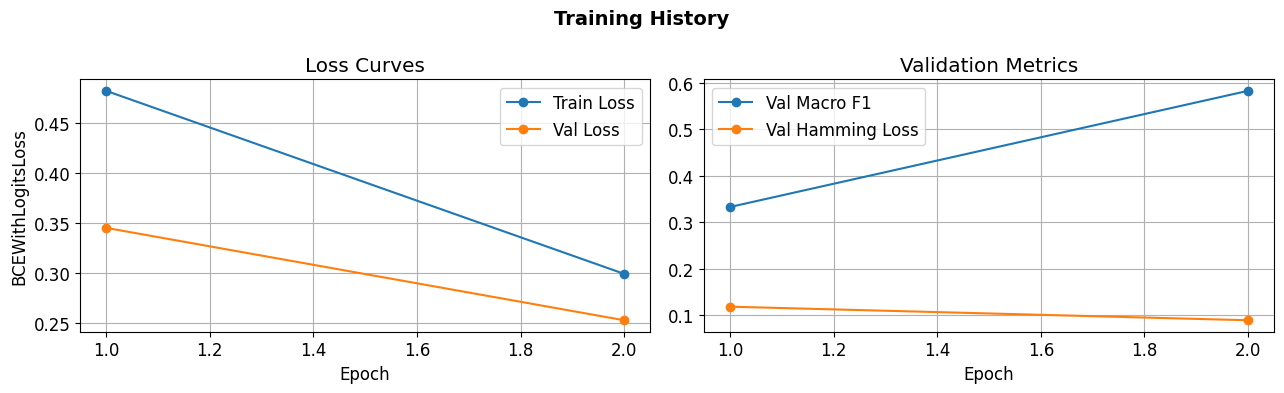

In [12]:
# Plot loss and validation metrics over epochs
hist_df = pd.DataFrame(history)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(hist_df['epoch'], hist_df['train_loss'], marker='o', label='Train Loss')
ax1.plot(hist_df['epoch'], hist_df['val_loss'],   marker='o', label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCEWithLogitsLoss')
ax1.set_title('Loss Curves')
ax1.legend()
ax1.grid(True)

ax2.plot(hist_df['epoch'], hist_df['val_f1'],      marker='o', label='Val Macro F1')
ax2.plot(hist_df['epoch'], hist_df['val_hamming'], marker='o', label='Val Hamming Loss')
ax2.set_xlabel('Epoch')
ax2.set_title('Validation Metrics')
ax2.legend()
ax2.grid(True)

plt.suptitle('Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 8 — Test Set Evaluation

Reloads the best checkpoint from disk and evaluates on the held-out test split.  
The test set is **only touched here** — never during training or hyperparameter tuning.

**Metrics reported:**
- **Exact Match Accuracy** — fraction of images where *every* label is predicted correctly
- **Hamming Loss** — fraction of individual label predictions that are wrong (lower = better)
- **Macro F1** — per-class F1 averaged equally over all classes
- **Micro F1** — F1 computed globally across all class predictions
- **Per-class F1** — useful for spotting which classes the model struggles with

**>> The printed numbers will go into the Results section of our report.**

In [13]:
# Load the best checkpoint (state dict) saved during training
best_model = create_model(num_labels=NUM_CLASSES, pretrained=False).to(DEVICE)
state_dict = torch.load(CHECKPOINT, map_location=DEVICE)
best_model.load_state_dict(state_dict)
best_model.eval()
print(f'Loaded "{CHECKPOINT}"  (best val F1 during training: {best_val_f1:.4f})')

# Full test pass
all_preds_t, all_labels_t = [], []
total_loss_t, total_n_t   = 0.0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = best_model(images)
        loss   = criterion(logits, labels)
        total_loss_t += loss.item() * images.size(0)
        total_n_t    += images.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= THRESHOLD).float()
        all_preds_t.append(preds.cpu().numpy())
        all_labels_t.append(labels.cpu().numpy())

test_loss     = total_loss_t / total_n_t
Y_pred        = np.vstack(all_preds_t)
Y_true        = np.vstack(all_labels_t)

exact_match   = (Y_pred == Y_true).all(axis=1).mean()
h_loss_test   = hamming_loss(Y_true, Y_pred)
f1_macro_test = f1_score(Y_true, Y_pred, average='macro',  zero_division=0)
f1_micro_test = f1_score(Y_true, Y_pred, average='micro',  zero_division=0)
per_class_f1  = f1_score(Y_true, Y_pred, average=None,     zero_division=0)

print('\n' + '=' * 55)
print('Test Set Evaluation -- EfficientNet-B0')
print('=' * 55)
print(f'  Test Loss        : {test_loss:.4f}')
print(f'  Exact Match Acc  : {exact_match:.4f}')
print(f'  Hamming Loss     : {h_loss_test:.4f}')
print(f'  Macro F1         : {f1_macro_test:.4f}')
print(f'  Micro F1         : {f1_micro_test:.4f}')
print('-' * 55)
print('  Per-class F1:')
for cls, f1 in zip(CLASS_NAMES, per_class_f1):
    print(f'    {cls:<12} {f1:.4f}')
print('=' * 55)
print('  >> These numbers go into the Results section of our report.')

Loaded "best_model.pth"  (best val F1 during training: 0.5830)

Test Set Evaluation -- EfficientNet-B0
  Test Loss        : 0.2568
  Exact Match Acc  : 0.3297
  Hamming Loss     : 0.0905
  Macro F1         : 0.5893
  Micro F1         : 0.5951
-------------------------------------------------------
  Per-class F1:
    pen          0.5660
    paper        0.6240
    book         0.4259
    clock        0.6667
    phone        0.3366
    laptop       0.6071
    chair        0.7129
    desk         0.6506
    bottle       0.4681
    keychain     0.3678
    backpack     0.9153
    calculator   0.7308
  >> These numbers go into the Results section of our report.


## Section 9 — Verify eval.py Compatibility

The graders run:
```
python eval.py --model_path best_model.pth --test_data project_test_data \
               --group_id YOUR_ID --project_title "YOUR_TITLE"
```

**What eval.py expects:**

1. `--model_path` must be a **state dict** `.pth` file.  
   eval.py line 133–134: `state_dict = torch.load(model_path, ...)` then  
   `model.load_state_dict(state_dict)`.  
   Our `torch.save(model.state_dict(), CHECKPOINT)` in Section 7 already satisfies this. ✓

2. Line 127 in `load_trained_model` contains the placeholder  
   `model = CREATE_YOUR_MODEL_HERE(num_labels=num_labels)`.  
   **Action:** The `create_model` function has replaced that line in eval.py.

In [14]:
# Step 1: Verify best_model.pth is a state dict (dict of weight tensors)
state_check = torch.load(CHECKPOINT, map_location='cpu')
assert isinstance(state_check, dict), 'Checkpoint is not a state dict -- re-run Section 7!'
print(f'[OK] "{CHECKPOINT}" is a state dict ({len(state_check)} keys).')

# Step 2: Confirm create_model() builds the right architecture and loads the checkpoint
_verify = create_model(num_labels=NUM_CLASSES, pretrained=False)
_verify.load_state_dict(state_check)
_verify.eval()
with torch.no_grad():
    _dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
    _out   = _verify(_dummy)
assert list(_out.shape) == [2, NUM_CLASSES], f'Unexpected output shape: {_out.shape}'
print(f'[OK] create_model() loads the checkpoint; output shape {list(_out.shape)}.')
del _verify, _dummy, _out, state_check

# Step 3: Print the exact function to paste into eval.py
print('\n' + '=' * 65)
print('ACTION REQUIRED -- paste the function below into eval.py')
print('and replace line 127 with:  model = create_model(num_labels=num_labels)')
print('=' * 65)
print('def create_model(num_labels=12, pretrained=False):')
print('    from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights')
print('    import torch.nn as nn')
print('    weights = EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None')
print('    model   = efficientnet_b0(weights=weights)')
print('    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_labels)')
print('    return model')
print('=' * 65)

[OK] "best_model.pth" is a state dict (360 keys).
[OK] create_model() loads the checkpoint; output shape [2, 12].

ACTION REQUIRED -- paste the function below into eval.py
and replace line 127 with:  model = create_model(num_labels=num_labels)
def create_model(num_labels=12, pretrained=False):
    from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
    import torch.nn as nn
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
    model   = efficientnet_b0(weights=weights)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_labels)
    return model
